In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

* X` is the preprocessed input data of shape (3492, 50, 8)
* corresponding asset returns `R` of shape (3492, 4)

* Each row contains [r_stock, r_bond, r_commodity, r_volatility]

In [2]:
X = np.load('X_data.npy')
R = np.load('Y_data.npy')

In [3]:
R_test = R[1280:] 

### Fixed Allocation methods

* Allocation 1 (25% shares, 25% bonds, 25% commodities and 25% volatility index)

* Allocation 2 (50% shares, 10% bonds, 20% commodities, and 20% volatility index)

* Allocation 3 (10% shares, 50% bonds, 20% commodities, and 20% volatility index)

* Allocation 4 (40% shares, 40% bonds, 10% commodities and 10% volatility index).

In [4]:
allocations = {
    "Allocation 1": np.array([0.25, 0.25, 0.25, 0.25]),
    "Allocation 2": np.array([0.50, 0.10, 0.20, 0.20]),
    "Allocation 3": np.array([0.10, 0.50, 0.20, 0.20]),
    "Allocation 4": np.array([0.40, 0.40, 0.10, 0.10])
}

In [5]:
vol_target = 0.10          # Target volatility (annualized)
transaction_cost = 0.0001         # Transaction cost per trade (0.01%)
window = 50

In [6]:
def ewma_volatility(returns, window=50):
    vol = np.zeros_like(returns)
    alpha = 2 / (window + 1)
    for i in range(1, len(returns)):
        vol[i] = np.sqrt(alpha * returns[i - 1]**2 + (1 - alpha) * vol[i - 1]**2)
    return vol

In [7]:
strategy_results = {}
vol = ewma_volatility(R_test, window)


### Evaluation metrics

In [8]:
def evaluate_performance(returns, trading_days=252):
    returns = np.array(returns)
    mean = np.mean(returns)
    std = np.std(returns)
    sharpe = mean / (std + 1e-8) * np.sqrt(trading_days)

    downside = returns[returns < 0]
    dd_std = np.std(downside) if len(downside) > 0 else 0
    sortino = mean / (dd_std + 1e-8) * np.sqrt(trading_days)

    cum_returns = np.cumprod(1 + returns)
    peak = np.maximum.accumulate(cum_returns)
    drawdowns = (cum_returns - peak) / peak
    max_dd = np.min(drawdowns)

    pct_pos = np.sum(returns > 0) / len(returns)
    avg_gain = np.mean(returns[returns > 0]) if np.any(returns > 0) else 0
    avg_loss = -np.mean(returns[returns < 0]) if np.any(returns < 0) else 1e-8
    pl_ratio = avg_gain / avg_loss if avg_loss > 0 else 0

    return {
        "Annualized Return (E[R])": mean * trading_days,
        "Annualized Std Dev (Std[R])": std * np.sqrt(trading_days),
        "Sharpe Ratio": sharpe,
        "Downside Deviation": dd_std * np.sqrt(trading_days),
        "Sortino Ratio": sortino,
        "Max Drawdown (MDD)": max_dd,
        "% Positive Returns": pct_pos,
        "Avg P / Avg L": pl_ratio,
        "Cumulative Returns": cum_returns
    }

### Simulating and evaluating

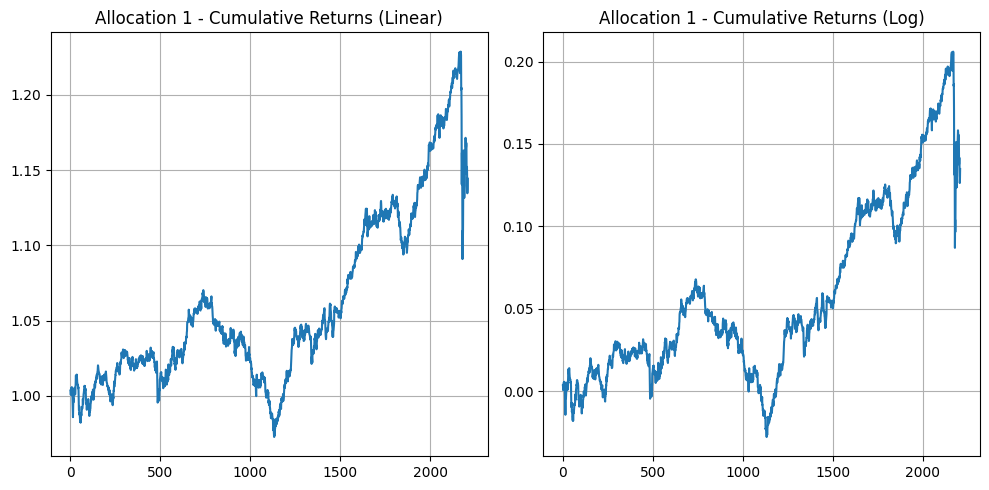

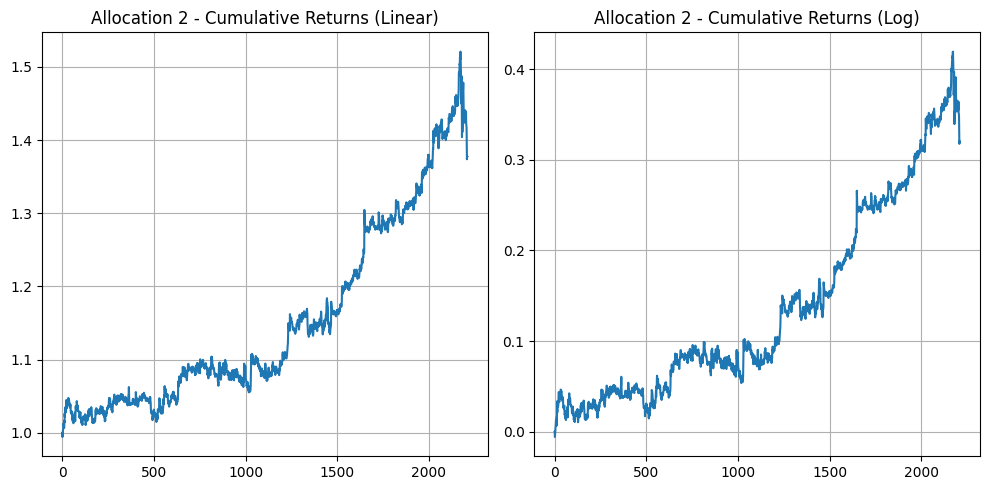

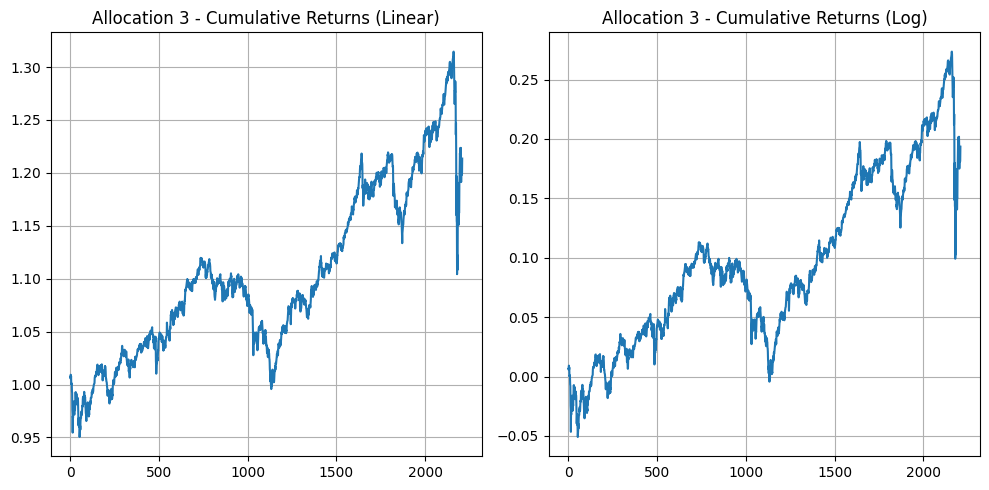

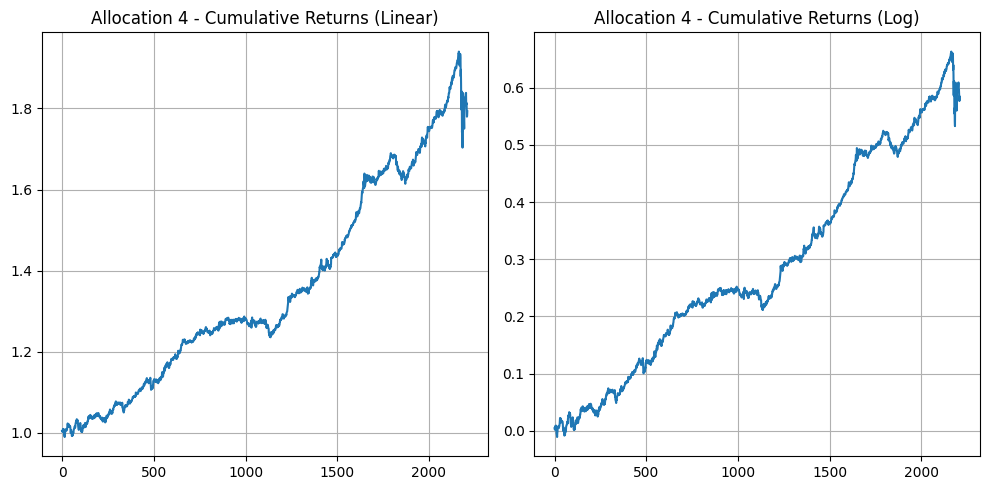

In [10]:
for name, alloc in allocations.items():
    returns = []
    n_assets = R_test.shape[1]
    weights = alloc.copy()
    scaled_weights_prev = np.zeros(n_assets)
    scaled_weights_2prev = np.zeros(n_assets)

    for t in range(2, len(R_test)):
        vol_adj = vol[t - 1]
        scale_factors = vol_target / (vol_adj + 1e-8)
        scaled_weights = weights * scale_factors
        scaled_weights /= np.sum(np.abs(scaled_weights))

        # Portfolio return
        daily_return = np.dot(scaled_weights, R_test[t])

        # Transaction cost
        cost_term = np.sum(np.abs(scaled_weights - scaled_weights_prev)) * transaction_cost
        daily_return -= cost_term

        returns.append(daily_return)
        scaled_weights_2prev = scaled_weights_prev
        scaled_weights_prev = scaled_weights

    metrics = evaluate_performance(returns)
    strategy_results[name] = metrics
    #print(metrics)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(metrics["Cumulative Returns"], label=name)
    plt.title(f"{name} - Cumulative Returns (Linear)")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(np.log(metrics["Cumulative Returns"] + 1e-8), label=name)
    plt.title(f"{name} - Cumulative Returns (Log)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [11]:
print("\nPerformance Summary (Volatility Scaled + 0.01% Cost):")
for name, metrics in strategy_results.items():
    print(f"\n{name}")
    for k, v in metrics.items():
        if isinstance(v, (np.ndarray, list)):
            print(f"{k}: array of length {len(v)}")
        else:
            print(f"{k}: {v:.4f}")



Performance Summary (Volatility Scaled + 0.01% Cost):

Allocation 1
Annualized Return (E[R]): 0.0163
Annualized Std Dev (Std[R]): 0.0420
Sharpe Ratio: 0.3869
Downside Deviation: 0.0379
Sortino Ratio: 0.4296
Max Drawdown (MDD): -0.1123
% Positive Returns: 0.5353
Avg P / Avg L: 0.9379
Cumulative Returns: array of length 2210

Allocation 2
Annualized Return (E[R]): 0.0385
Annualized Std Dev (Std[R]): 0.0621
Sharpe Ratio: 0.6191
Downside Deviation: 0.0391
Sortino Ratio: 0.9841
Max Drawdown (MDD): -0.0967
% Positive Returns: 0.4923
Avg P / Avg L: 1.1572
Cumulative Returns: array of length 2210

Allocation 3
Annualized Return (E[R]): 0.0239
Annualized Std Dev (Std[R]): 0.0600
Sharpe Ratio: 0.3977
Downside Deviation: 0.0542
Sortino Ratio: 0.4408
Max Drawdown (MDD): -0.1600
% Positive Returns: 0.5462
Avg P / Avg L: 0.9004
Cumulative Returns: array of length 2210

Allocation 4
Annualized Return (E[R]): 0.0679
Annualized Std Dev (Std[R]): 0.0516
Sharpe Ratio: 1.3157
Downside Deviation: 0.0430
S